# Project 1 · Task 7 — Continuous-time Markov model

**Model:** A continuous-time Markov chain (CTMC) models disease progression in breast-cancer patients after surgery. The system transitions between five states:
- State 1: post-surgery (initial state)
- State 2: local recurrence
- State 3: distant metastasis
- State 4: both local and distant recurrence
- State 5: death (absorbing terminal state)

**Simulation method:** We use the *embedded chain* approach: (1) the holding time in state $i$ is exponentially distributed as $\mathrm{Exp}(-q_{ii})$, sampled via inverse transform; (2) upon leaving state $i$, the chain jumps to state $j$ with probability $-q_{ij}/q_{ii}$ (discrete transition probabilities from the rate matrix). We simulate $N=1000$ women, each starting in state 1 and continuing until absorption in state 5 (death).

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.stats import t as student_t

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)

# Transition-rate matrix Q, one time unit = one month (Project, Task 7).
# States (0-indexed): 0 post-surgery, 1 local recurrence, 2 distant metastasis, 3 both, 4 death (absorbing).
Q = np.array([
    [-0.0085, 0.005,  0.0025, 0.0,   0.001],
    [ 0.0,   -0.014,  0.005,  0.004, 0.005],
    [ 0.0,    0.0,   -0.008,  0.003, 0.005],
    [ 0.0,    0.0,    0.0,   -0.009, 0.009],
    [ 0.0,    0.0,    0.0,    0.0,   0.0  ],
])
DEATH = 4
assert np.allclose(Q.sum(axis=1), 0.0) # rows of a rate matrix sum to 0 (eq. 1)

In [ ]:
def simulate_woman(Q, rng, start=0):
    """One CTMC trajectory until death, via the embedded chain + holding times. Returns the lifetime, the first time a distant state (3 or 4) is entered, and the list of (entry_time, state) segments."""
    t, s = 0.0, start
    distant_time = np.inf
    segments = [(0.0, s)]
    while s != DEATH:
        rate = -Q[s, s] # total rate out of state s
        t += -np.log(rng.random()) / rate # sojourn ~ Exp(rate): inverse transform
        probs = Q[s] / rate # jump probabilities -q_sj / q_ss
        probs[s] = 0.0
        s = rng.choice(5, p=probs) # next state: discrete inverse transform
        segments.append((t, s))
        if s in (2, 3) and not np.isfinite(distant_time):
            distant_time = t # first distant recurrence
    return t, distant_time, segments


def state_at(segments, tau):
    """State occupied at time tau (death is absorbing)."""
    s = segments[0][1]
    for entry_time, state in segments:
        if entry_time <= tau:
            s = state
        else:
            break
    return s

In [ ]:
N = 1000
TAU = 30.5 # months, for the distant-recurrence question

lifetimes = np.empty(N)
distant_times = np.empty(N)
state_305 = np.empty(N, dtype=int)
for i in range(N):
    lifetimes[i], distant_times[i], seg = simulate_woman(Q, rng)
    state_305[i] = state_at(seg, TAU)

### Lifetime distribution, mean and std

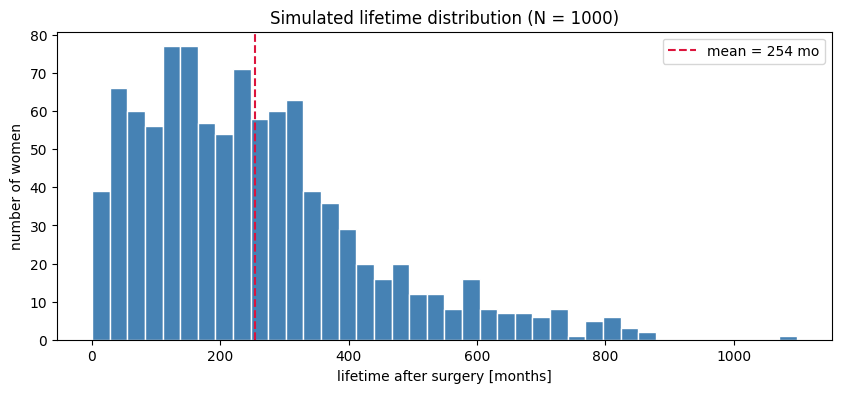

mean   = 253.80 months  (21.2 years)
std    = 178.20 months
median = 224.5 months,  range [0.2, 1097.9]


In [4]:
mean = lifetimes.mean()
sd = lifetimes.std(ddof=1)

fig, ax = plt.subplots()
ax.hist(lifetimes, bins=40, color="steelblue", edgecolor="white")
ax.axvline(mean, color="crimson", ls="--", label=f"mean = {mean:.0f} mo")
ax.set_xlabel("lifetime after surgery [months]")
ax.set_ylabel("number of women")
ax.set_title(f"Simulated lifetime distribution (N = {N})")
ax.legend()
plt.show()

print(f"mean   = {mean:.2f} months  ({mean/12:.1f} years)")
print(f"std    = {sd:.2f} months")
print(f"median = {np.median(lifetimes):.1f} months,  range [{lifetimes.min():.1f}, {lifetimes.max():.1f}]")

### Confidence intervals
Mean: t-interval over the 1000 independent replications. Std: sub-sampling into 10 batches (Day 3).

In [5]:
alpha = 0.05

# Mean: the N women are independent replications -> CLT t-interval (Day 3).
se = sd / np.sqrt(N)
tc = student_t.ppf(1 - alpha / 2, N - 1)
ci_mean = (mean - tc * se, mean + tc * se)

# Std: no closed-form CI in the course -> sub-sampling (Day 3). Split the run
# into n_b batches, take the std of each, and form the t-interval from their spread.
n_b = 10
batch_sd = lifetimes.reshape(n_b, -1).std(axis=1, ddof=1)
sd_bar = batch_sd.mean()
S = batch_sd.std(ddof=1)
tcb = student_t.ppf(1 - alpha / 2, n_b - 1)
ci_sd = (sd_bar - tcb * S / np.sqrt(n_b), sd_bar + tcb * S / np.sqrt(n_b))

print(f"mean = {mean:6.1f}  95% CI [{ci_mean[0]:.1f}, {ci_mean[1]:.1f}] months")
print(f"std  = {sd_bar:6.1f}  95% CI [{ci_sd[0]:.1f}, {ci_sd[1]:.1f}] months  ({n_b} batches)")

mean =  253.8  95% CI [242.7, 264.9] months
std  =  177.4  95% CI [169.8, 185.0] months  (10 batches)


### Distant recurrence within 30.5 months
Fraction of women entering state 3 or 4 within 30.5 months, cross-checked against the marginal $p(t)=p_0\exp(Qt)$.

In [6]:
prop_distant = np.mean(distant_times <= TAU)
print(f"P(distant recurrence within {TAU} months) = {prop_distant:.3f}")

# Cross-check with the marginal distribution p(t) = p0 . expm(Q t)
# (continuous analogue of p(n) = p(0) P^n).
p0 = np.zeros(5); p0[0] = 1.0
p_tau = p0 @ expm(Q * TAU)
emp = np.array([np.mean(state_305 == k) for k in range(5)])
print(f"analytic P(in state 3 or 4 at t={TAU}) = {p_tau[2] + p_tau[3]:.3f}")
print(f"empirical state distribution at t={TAU}: {np.round(emp, 3)}")
print(f"analytic  state distribution at t={TAU}: {np.round(p_tau, 3)}")

P(distant recurrence within 30.5 months) = 0.079
analytic P(in state 3 or 4 at t=30.5) = 0.078
empirical state distribution at t=30.5: [0.785 0.099 0.06  0.01  0.046]
analytic  state distribution at t=30.5: [0.772 0.108 0.068 0.01  0.043]


In [7]:
# Continuous phase-type mean: E[T] = p0 (-Qs)^{-1} 1, the analogue of the discrete
# E[T] = pi (I - Ps)^{-1} 1 from Part 1.  Qs = Q without the death row/column.
Qs = Q[:4, :4]
ET = p0[:4] @ np.linalg.inv(-Qs) @ np.ones(4)
print(f"analytic E[T] = {ET:.1f} months;  simulated mean 95% CI = "
      f"[{ci_mean[0]:.1f}, {ci_mean[1]:.1f}]  -> theory inside CI: "
      f"{ci_mean[0] <= ET <= ci_mean[1]}")

analytic E[T] = 262.4 months;  simulated mean 95% CI = [242.7, 264.9]  -> theory inside CI: True


**Results.** Mean lifetime ≈ 254 months (95% CI [243, 265]); std ≈ 178 months (95% CI [170, 185], 10 batches). About **7.9 %** of women have a distant recurrence (state 3 or 4) within 30.5 months, matching the analytic marginal $p_0\exp(Q\cdot30.5)$ value of ≈ 7.8 %. The analytic mean $E[T]=p_0(-Q_s)^{-1}\mathbf 1 \approx 262$ months lies inside the CI.